In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keplerprop import *
plt.style.use('custom_paper')

In [2]:
G = 1
M = 1

In [3]:
a,e,i,omega,Omega,M0 = 1.0, 0.7, 0, 70.0, 0.0, 0.0
mu= G*M
P = 2*np.pi*np.sqrt(a**3/mu)
dtgrid = np.random.uniform(0,P,50000000)
rkep,vkep = compute_trajectory(dtgrid,[a,e,i,omega,Omega,M0],mu)

In [4]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from scipy.special import roots_legendre

N_QUAD = 4096 * 4
nodes_np, weights_np = roots_legendre(N_QUAD)

thetas_base_np = nodes_np
wts_base_np = weights_np

thetas_base_jax = jnp.asarray(thetas_base_np)
wts_base_jax = jnp.asarray(wts_base_np)

@jax.jit
def phi_num_ad_scalar(x0, y0, z0, a, e, omega, theta_min, theta_max):
    r0 = jnp.sqrt(x0**2 + y0**2)
    theta0 = jnp.arctan2(y0, x0)

    L = theta_max - theta_min
    L = jnp.where(L <= 0.0, L + 2.0 * jnp.pi, L)

    half = 0.5 * L
    center = theta_min + half
    thetas = center + half * thetas_base_jax
    wts    = wts_base_jax * half

    cos_domega = jnp.cos(thetas - omega)
    denom1     = 1.0 + e * cos_domega
    one_me2    = 1.0 - e**2

    R_theta = a * one_me2 / denom1

    d = jnp.sqrt(r0**2 + z0**2 + R_theta**2 - 2.0 * R_theta * r0 * jnp.cos(thetas - theta0))

    P_theta = (one_me2**1.5) / (2.0 * jnp.pi * denom1**2)

    integral = -M*jnp.sum(wts * P_theta / d)
    return integral 
grad_phi_cart = jax.grad(phi_num_ad_scalar, argnums=(0, 1, 2))

@jax.jit
def accel_cyl_scalar(x0, y0, z0, a, e, omega, dtheta, Theta0):
    gx, gy, gz = grad_phi_cart(x0, y0, z0, a, e, omega, dtheta, Theta0)

    ax = -gx
    ay = -gy
    az = -gz

    r = jnp.sqrt(x0**2 + y0**2)
    r_safe = jnp.where(r > 1e-12, r, 1e-12)  # Avoid division by zero

    ar = (x0 * ax + y0 * ay) / r_safe

    atheta = (x0 * ay - y0 * ax) / r_safe

    return ar, atheta, az

In [5]:
def average_potential_on_grid_streaming(positions,X, Y,softening=1e-6,batch_size=256):
    ny, nx = X.shape
    P = nx * ny

    Xf = X.ravel()[None, :]   # (1, P)
    Yf = Y.ravel()[None, :]   # (1, P)

    phi_sum = np.zeros(P)

    N = positions.shape[0]
    sx2 = softening**2

    for i in range(0, N, batch_size):
        chunk = positions[i:i+batch_size]
        rx = chunk[:, 0:1]    # (B,1)
        ry = chunk[:, 1:2]    # (B,1)

        if chunk.shape[1] > 2:
            rz = chunk[:, 2:3]
            R2 = (Xf - rx)**2 + (Yf - ry)**2 + rz**2 + sx2
        else:
            R2 = (Xf - rx)**2 + (Yf - ry)**2 + sx2

        R = np.sqrt(R2)       # (B, P)
        phi_sum += (-G * M / R).sum(axis=0)

    Phi_avg = (phi_sum / N).reshape(ny, nx)
    return Phi_avg


In [6]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)

In [7]:
z0 = 0.1
rkep[:,2] = z0
phi_brute = average_potential_on_grid_streaming(rkep,X, Y,softening=1e-6,batch_size=256)

In [8]:
dtheta = np.pi
Theta0 = np.radians(omega)

In [9]:
phi_num_vals = np.zeros_like(X)

ar_num = np.zeros_like(X)
atheta_num = np.zeros_like(X)
az_num = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = X[i, j]
        y = Y[i, j]

        phi_num_vals[i,j] = float(phi_num_ad_scalar(x, y, z0, a, e, np.radians(omega), 0, 2*np.pi))
        a_r, a_theta, a_z = accel_cyl_scalar(x, y, z0, a, e, omega, dtheta, Theta0)
        ar_num[i, j] = float(a_r)
        atheta_num[i, j] = float(a_theta)
        az_num[i, j] = float(a_z)

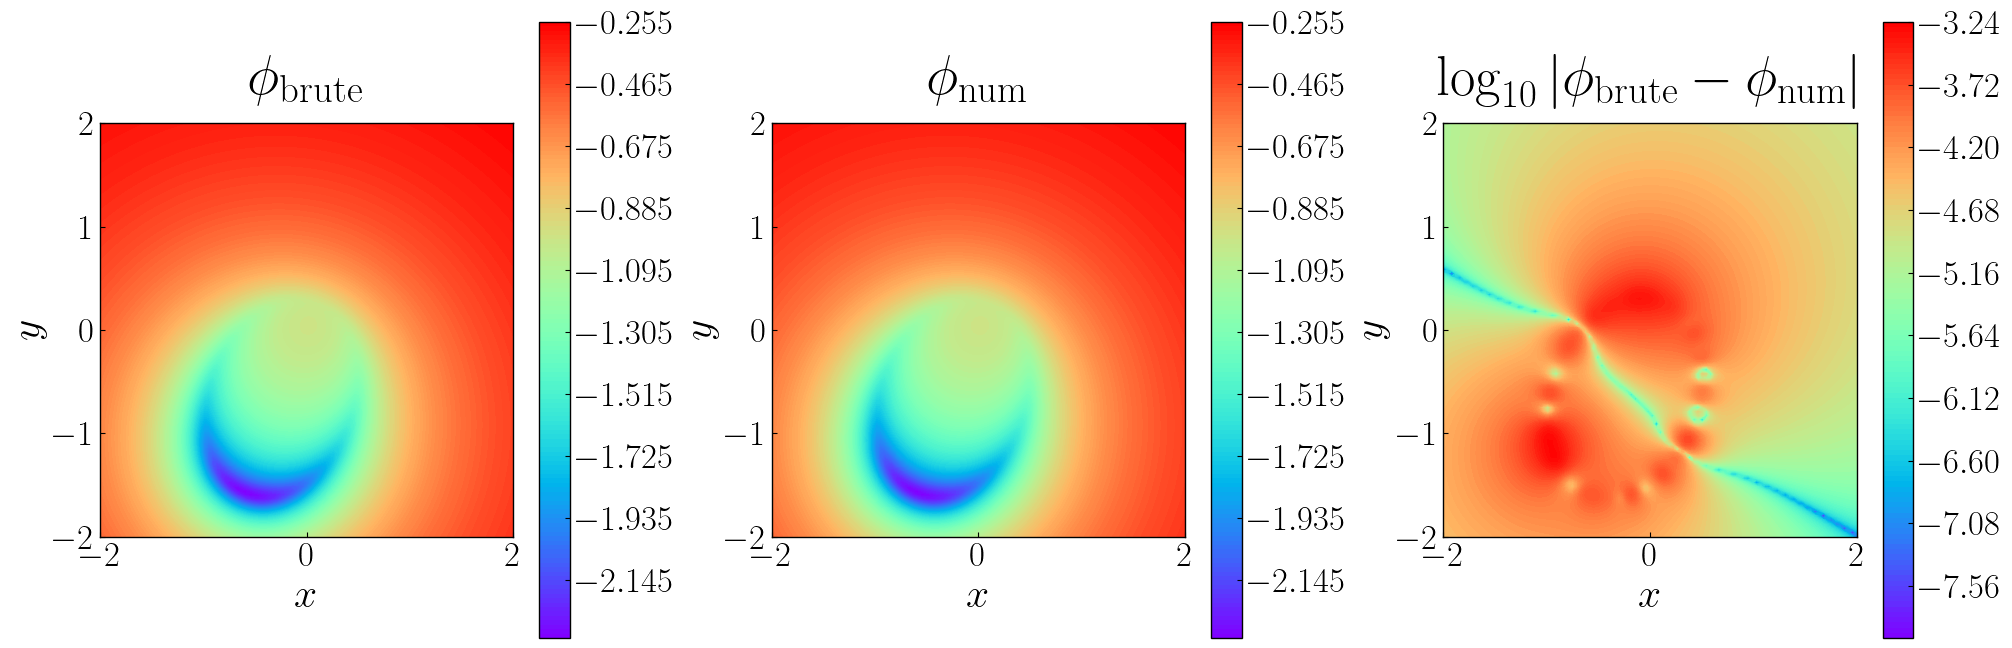

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.subplots_adjust(wspace=0.3, hspace=0.35)

axes[0].set_title(r"$\phi_{\mathrm{brute}}$")
im0 = axes[0].contourf(X, Y, phi_brute, 150, cmap='rainbow')
fig.colorbar(im0, ax=axes[0])
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_aspect('equal', adjustable='box')  

axes[1].set_title(r"$\phi_{\mathrm{num}}$")
im1 = axes[1].contourf(X, Y, phi_num_vals, 150, cmap='rainbow')
fig.colorbar(im1, ax=axes[1])
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].set_aspect('equal', adjustable='box')

axes[2].set_title(r"$\log_{10}|\phi_{\mathrm{brute}} - \phi_{\mathrm{num}}|$")
diff = np.log10(np.abs(phi_brute - phi_num_vals))
im2 = axes[2].contourf(X, Y, diff, 150, cmap='rainbow')
fig.colorbar(im2, ax=axes[2])
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
axes[2].set_aspect('equal', adjustable='box')

plt.savefig("planetary_phi_brute_num.png", dpi=300, bbox_inches="tight")
plt.show()
